# 10-4 ImageFolder (2)

## Image Classification
In this notebook, we will train a model to classify images of chairs into grey and red.

Part of the training data is like:
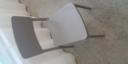
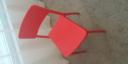

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import torch.optim as optim
from torch.utils.data import DataLoader

import torchvision
import torchvision.transforms as transforms

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

torch.manual_seed(777)
if device =='cuda':
    torch.cuda.manual_seed_all(777)

In [3]:
trans = transforms.Compose([
    transforms.ToTensor()
])

train_data = torchvision.datasets.ImageFolder(root='./custom_data/train_data', transform=trans)

In [4]:
data_loader = DataLoader(dataset = train_data, batch_size = 8, shuffle = True, num_workers=2)

In [ ]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.layer1 = nn.Sequential(
            # shape: (3, 64, 128)
            nn.Conv2d(3,6,5),
            #convolution: Input channels: 6 Output channels: 16 Kernel size: 5x5
            # shape: (6, 60, 124)
            nn.ReLU(),
            nn.MaxPool2d(2), #pooling 
            # shape: (6, 30, 62)
        )
        self.layer2 = nn.Sequential(
            nn.Conv2d(6,16,5),
            # shape: (16, 26, 58)
            nn.ReLU(),
            nn.MaxPool2d(2),
            # shape: (16, 13, 29)
        )
        self.layer3 = nn.Sequential(
            nn.Linear(16*13*29, 120),
            nn.ReLU(),
            nn.Linear(120,2)
        )
        
    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = out.view(out.shape[0], -1)
        out = self.layer3(out)
        return out
        

This cell is performing a basic sanity test of the CNN model before training to ensure the network architecture works as expected with the input dimensions.

In [ ]:
#testing 
net = CNN().to(device)
test_input = (torch.Tensor(3,3,64,128)).to(device) #batch size: 3, channel: 3(RGB), height: 64, width: 128
test_out = net(test_input)
print(test_out)

<built-in method size of Tensor object at 0xffc511f30780>


In [7]:
optimizer = optim.Adam(net.parameters(), lr=0.00005)
loss_func = nn.CrossEntropyLoss().to(device)

In [8]:
total_batch = len(data_loader)

epochs = 7
for epoch in range(epochs):
    avg_cost = 0.0
    for num, data in enumerate(data_loader):
        imgs, labels = data
        imgs = imgs.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        out = net(imgs)
        loss = loss_func(out, labels)
        loss.backward()
        optimizer.step()
        
        avg_cost += loss / total_batch
        
    print('[Epoch:{}] cost = {}'.format(epoch+1, avg_cost))
print('Learning Finished!')   

[Epoch:1] cost = 0.654131293296814
[Epoch:2] cost = 0.4932667315006256
[Epoch:3] cost = 0.22231119871139526
[Epoch:4] cost = 0.06608392298221588
[Epoch:5] cost = 0.02621614746749401
[Epoch:6] cost = 0.013924773782491684
[Epoch:7] cost = 0.008714674040675163
Learning Finished!


## Model saving and testing
Here's how to save a model for future use.

In [10]:
torch.save(net.state_dict(), "./model/model.pth")

And how to load it.

In [11]:
new_net = CNN().to(device)
new_net.load_state_dict(torch.load('./model/model.pth'))

/tmp/ipykernel_3326/3252664018.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  new_net.load_state_dict(torch.load('./model/model.pth'))


<All keys matched successfully>

Show the parameters of the model.

In [12]:
print(net.layer1[0])
print(new_net.layer1[0])

print(net.layer1[0].weight[0][0][0])
print(new_net.layer1[0].weight[0][0][0])

net.layer1[0].weight[0] == new_net.layer1[0].weight[0]

Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
tensor([-0.0913,  0.0032, -0.0172, -0.0214,  0.0930],
       grad_fn=<SelectBackward0>)
tensor([-0.0913,  0.0032, -0.0172, -0.0214,  0.0930],
       grad_fn=<SelectBackward0>)


tensor([[[True, True, True, True, True],
         [True, True, True, True, True],
         [True, True, True, True, True],
         [True, True, True, True, True],
         [True, True, True, True, True]],

        [[True, True, True, True, True],
         [True, True, True, True, True],
         [True, True, True, True, True],
         [True, True, True, True, True],
         [True, True, True, True, True]],

        [[True, True, True, True, True],
         [True, True, True, True, True],
         [True, True, True, True, True],
         [True, True, True, True, True],
         [True, True, True, True, True]]])

Now test the accuracy.

In [13]:
trans=torchvision.transforms.Compose([
    transforms.Resize((64,128)),
    transforms.ToTensor()
])
test_data = torchvision.datasets.ImageFolder(root='./custom_data/test_data', transform=trans)

In [14]:
test_set = DataLoader(dataset = test_data, batch_size = len(test_data))

In [15]:
with torch.no_grad():
    for num, data in enumerate(test_set):
        imgs, label = data
        imgs = imgs.to(device)
        label = label.to(device)
        
        prediction = net(imgs)
        
        correct_prediction = torch.argmax(prediction, 1) == label
        
        accuracy = correct_prediction.float().mean()
        print('Accuracy:', accuracy.item())

Accuracy: 1.0
